# Interbank Challengue - Data Science

**Contexto del Desafío**

Un banco líder ha identificado un incremento en problemas dentro de su cartera de préstamos. Durante los últimos 3 años se ha recopilado información histórica de otorgación
crediticia.  
El objetivo es transformar el proceso tradicional mediante un sistema de pre-evaluación automatizado basado en Machine Learning.

**El Reto**

Diseñar un modelo predictivo que estime la probabilidad de que un cliente experimente dificultades financieras en los próximos 24 meses. El modelo deberá mejorar la predicción del riesgo y apoyar decisiones estratégicas.

**Objetivos Clave**

- Construcción de variables de comportamiento histórico (preprocesamiento).
- Manejo de desbalance de datos
- Validación temporal del modelo.
- Definición de cutoff óptimo.
- Evaluación con métricas: AUC, GINI y Recall del modelo.
- Diseño del Testing A/B
- Definir el flujo de implementación en el canal de digital (mailing).

**Impacto Esperado**

- Mejor control del riesgo crediticio.
- Disminución de deterioro de cartera.
- Toma de decisiones basada en datos.
- Mayor eficiencia en la aprobación de préstamos

# Import libraries

In [1]:
import re
import math
import pandas as pd
import numpy as np
import json
from pandas import json_normalize
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve
)
from lightgbm import LGBMClassifier

# Functions

# Lectura de fuentes

## Diccionario de Datos – Modelo de Riesgo Crediticio

| Nombre variable | Descripción | Tipo |
|-----------------|------------|------|
| **Default** | Cliente con más de 90 días sin pagar su préstamo | Y/N |
| **Prct_uso_tc** | Porcentaje del uso de tarjeta de crédito el último mes | Percentage |
| **Edad** | Edad del cliente | Integer |
| **Nro_prestao_retrasados** | Número de préstamos con retraso en el pago de más de 3 meses en los últimos 3 años | Integer |
| **Prct_deuda_vs_ingresos** | Ratio de deuda financiera vs ingresos del cliente | Percentage |
| **Mto_ingreso_mensual** | Monto de ingreso mensual | Real |
| **Nro_prod_financieros_deuda** | Número de préstamos (incluye créditos vehiculares o hipotecarios) y número de tarjetas de crédito último año | Integer |
| **Nro_retraso_60dias** | Número de veces que el cliente se ha retrasado más de 60 días en los últimos 3 años | Integer |
| **Nro_creditos_hipotecarios** | Número de créditos hipotecarios | Integer |
| **Nro_retraso_ultm3anios** | Número de retrasos en pagos de más de 30 días en los últimos 3 años | Integer |
| **Nro_dependiente** | Número de dependientes | Integer |

---

## Variable Objetivo

**Default**  
- Y (1) = Cliente con más de 90 días de mora  
- N (0)= Cliente sin mora significativa  

Tipo de problema: **Clasificación Binaria (Riesgo Crediticio)**

In [2]:
# Leer dataset
credit_data = pd.read_csv("Dataset/Dataset.csv")
# Ver primeras filas
credit_data.head()

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print(credit_data.shape)
credit_data.info()
credit_data["Default"].value_counts(normalize=True)

(150000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          150000 non-null  int64  
 1   Default                     150000 non-null  int64  
 2   Prct_uso_tc                 150000 non-null  float64
 3   Edad                        150000 non-null  int64  
 4   Nro_prestao_retrasados      150000 non-null  int64  
 5   Prct_deuda_vs_ingresos      150000 non-null  float64
 6   Mto_ingreso_mensual         120269 non-null  float64
 7   Nro_prod_financieros_deuda  150000 non-null  int64  
 8   Nro_retraso_60dias          150000 non-null  int64  
 9   Nro_creditos_hipotecarios   150000 non-null  int64  
 10  Nro_retraso_ultm3anios      150000 non-null  int64  
 11  Nro_dependiente             146076 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 13.7 MB


Default
0    0.93316
1    0.06684
Name: proportion, dtype: float64

In [4]:
credit_data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
Default,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
Prct_uso_tc,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Edad,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
Nro_prestao_retrasados,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
Prct_deuda_vs_ingresos,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
Mto_ingreso_mensual,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
Nro_prod_financieros_deuda,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
Nro_retraso_60dias,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
Nro_creditos_hipotecarios,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0


**Insights**:

- Dataset desbalanceado (minoría positiva): ~6.7% de casos default.
    Esto implica:
    - No usar accuracy.
    - Usar ROC-AUC.
    - Considerar class_weight o ajuste de threshold.
- Variables Percentage mal escaladas:
    - ``Prct_uso_tc``: Mean = 6.04, Max = 50708
    - ``Prct_deuda_vs_ingresos``: Mean = 353, Max = 329664
    - No son porcentajes normales, implica revisión y posible tratamiento.
- Ingresos con valores extremos (``Mto_ingreso_mensual``)
    - Mean = 6670, Max = 3008750
    - Requiere tratamiento (Log transform, Winsorization, Outlier capping)
- Missing values:
    - ``Mto_ingreso_mensual``: 120269. Hay ~30k faltantes
    - ``Nro_dependiente``: 146076. Hay ~4k faltantes
    - Ver posibilidad de imputación
- Variables de mora (``Nro_retraso_60dias``, ``Nro_retraso_ultm3anios``, ``Nro_prestao_retrasados``):
    - Todas tienen: Mediana = 0, 75% = 0
    - Muy sesgadas hacia cero.
    - Son variables típicas de riesgo crediticio, probablemente serán las más predictivas.


# 1. Preprocesamiento de datos

## 1.1 Copia de seguridad

Nunca trabajamos sobre el raw directamente:

In [5]:
credit_df = credit_data.copy()
credit_df.head()

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 1.2 Eliminación de variables no predictivas

``ID`` no debe entrar al modelo. Evita overfitting artificial y leakage indirecto.

In [6]:
credit_df.drop(columns=["ID"], inplace=True)

## 1.3 Validación del Target

Ya validado que Default está en formato binario (0/1), vamos a verificar distribución.

In [7]:
credit_df["Default"].value_counts(normalize=True)

Default
0    0.93316
1    0.06684
Name: proportion, dtype: float64

**Insights**:

- Confirma desbalance (~6.7%)


## 1.4 Evaluación de Calidad de Datos

### 1.4.1 Diagnóstico y corrección del ratio deuda/ingreso

La variable ``Prct_deuda_vs_ingresos`` presenta valores extremos. La discrepancia en la mediana se explica porque el grupo con ingreso faltante concentra valores extremos en el ratio deuda/ingreso, probablemente debido a ingresos nulos o muy bajos en el cálculo original. ¿Conviene recalcularlo luego de imputar ongresos o eliminar observaciones inconsistentes? Lo analicemos a continuación porque impacta en el tratamiento de valores nulos en los ingresos.

In [8]:
# Comparación real del ratio deuda/ingreso por grupo de ingreso nulo o no

ratio_missing = credit_df.loc[
    credit_df["Mto_ingreso_mensual"].isnull(),
    "Prct_deuda_vs_ingresos"
]

ratio_no_missing = credit_df.loc[
    credit_df["Mto_ingreso_mensual"].notnull(),
    "Prct_deuda_vs_ingresos"
]

ratio_missing.describe(percentiles=[0.9, 0.95, 0.99])

count     29731.000000
mean       1673.396556
std        4248.372895
min           0.000000
50%        1159.000000
90%        3785.000000
95%        4902.500000
99%        8084.500000
max      329664.000000
Name: Prct_deuda_vs_ingresos, dtype: float64

Mediana: 115,900% de deuda sobre ingreso
Eso solo puede ocurrir si:
- El ingreso usado en el cálculo fue 0 o cercano a 0
- O el ratio fue mal calculado cuando ingreso estaba faltante

In [9]:
ratio_no_missing.describe(percentiles=[0.9, 0.95, 0.99])

count    120269.000000
mean         26.598777
std         424.446457
min           0.000000
50%           0.296023
90%           0.763149
95%           1.128771
99%         661.820000
max       61106.500000
Name: Prct_deuda_vs_ingresos, dtype: float64

Aquí la distribución central es coherente.
Solo el 1% superior es problemático.

**Insights**:

- El ratio está contaminado estructuralmente en el grupo con ingreso missing.
- Esto no es simplemente un outlier aislado. Es un problema matemático:
    - El ratio fue calculado aunque el ingreso estuviera ausente o inválido.
    - Por eso el grupo missing tiene ratios gigantes.
- Opción 1: Imputar primero el ingreso. Recalcular el ratio correctamente.Pero no tenemos deuda absoluta, solo el ratio. Entonces no podemos recalcular.
- Opción 2: Para los casos donde ingreso es missing:
    - Reemplazar el ratio por NA
    - Luego imputarlo de forma consistente

In [10]:
# Regla: si ingreso es missing, el ratio no es confiable (vimos mediana 1159 en ese grupo).
# => invalidar ratio en esos casos y luego imputar desde la distribución "válida"
ratio_col = "Prct_deuda_vs_ingresos"
inc_col = "Mto_ingreso_mensual"

# Invalidar ratio cuando ingreso es NA
credit_df.loc[credit_df[inc_col].isnull(), ratio_col] = np.nan

# Imputar ratio con mediana del grupo con ingreso NO missing (distribución económicamente coherente)
ratio_median_valid = credit_df.loc[credit_df[inc_col].notnull(), ratio_col].median()
credit_df[ratio_col] = credit_df[ratio_col].fillna(ratio_median_valid)

# Límite económico del ratio (evita cola extrema no interpretable)
# En banca, ratio > 3 (300%) ya es extremo; elegimos 3 por interpretabilidad.
credit_df[ratio_col] = credit_df[ratio_col].clip(lower=0, upper=3)

### 1.4.2 Limpieza de valores atípicos

In [11]:
# Edad: remover edades inválidas y cap superior razonable
credit_df = credit_df[credit_df["Edad"] >= 18].copy()
credit_df["Edad"] = credit_df["Edad"].clip(upper=90)

In [12]:
# Dependientes: se tratará luego (por NA)
# Asegurar no negativos en conteos de mora y productos
count_cols = [
    "Nro_prestao_retrasados",
    "Nro_prod_financieros_deuda",
    "Nro_retraso_60dias",
    "Nro_creditos_hipotecarios",
    "Nro_retraso_ultm3anios",
    "Nro_dependiente"
]
for c in count_cols:
    if c in credit_df.columns:
        credit_df.loc[credit_df[c] < 0, c] = np.nan  # valores imposibles -> NA para imputar

### 1.4.3  Tratamiento de missing (nulos) en ingreso y dependientes

In [13]:
credit_df.isnull().mean().sort_values(ascending=False)

Mto_ingreso_mensual           0.198208
Nro_dependiente               0.026160
Default                       0.000000
Prct_uso_tc                   0.000000
Edad                          0.000000
Nro_prestao_retrasados        0.000000
Prct_deuda_vs_ingresos        0.000000
Nro_prod_financieros_deuda    0.000000
Nro_retraso_60dias            0.000000
Nro_creditos_hipotecarios     0.000000
Nro_retraso_ultm3anios        0.000000
dtype: float64

**Insights**:

Datos faltantes identificados:

- ``Mto_ingreso_mensual`` (~20%)

- ``Nro_dependiente`` (~2.6%)

**Analizar si el missing es aleatorio**

Pregunta clave: ¿Los clientes con ingreso faltante tienen mayor tasa de default?

**``Mto_ingreso_mensual``**

In [14]:
credit_df.groupby(
    credit_df["Mto_ingreso_mensual"].isnull()
)["Default"].mean()

Mto_ingreso_mensual
False    0.069486
True     0.056137
Name: Default, dtype: float64

**Insights**:

- La tasa de default es ligeramente menor cuando el ingreso es missing.
- La diferencia no parece grande (~1.3 pp).
- A simple vista, el missing no parece indicar mayor riesgo.

Esto sugiere que el missing podría ser:

- MCAR (Missing Completely At Random) O al menos no fuertemente asociado al target

**Comparar distribuciones**

Comparar comportamiento entre grupos.

In [15]:
cols_interes = [
    "Edad",
    "Prct_deuda_vs_ingresos",
    "Nro_retraso_60dias",
    "Nro_retraso_ultm3anios",
    "Nro_prestao_retrasados",
    "Default"
]

resumen = (
    credit_df
    .assign(ingreso_missing = credit_df["Mto_ingreso_mensual"].isnull())
    .groupby("ingreso_missing")[cols_interes]
    .mean()
)

resumen.loc[True] - resumen.loc[False]

Edad                      5.051526
Prct_deuda_vs_ingresos   -0.113788
Nro_retraso_60dias        0.272685
Nro_retraso_ultm3anios    0.265165
Nro_prestao_retrasados    0.198102
Default                  -0.013350
dtype: float64

In [16]:
# Comparar medianas en vez de medias (Porque los outliers están distorsionando la media)
credit_df.assign(
    ingreso_missing = credit_df["Mto_ingreso_mensual"].isnull()
).groupby("ingreso_missing")[cols_interes].median()

,Edad,Prct_deuda_vs_ingresos,Nro_retraso_60dias,Nro_retraso_ultm3anios,Nro_prestao_retrasados,Default
ingreso_missing,,,,,,
False,51.0,0.296021,0.0,0.0,0.0,0.0
True,57.0,0.296023,0.0,0.0,0.0,0.0


**Insights**:

El missing en ingreso:

- Está asociado a mayor edad
- NO muestra diferencia estructural en mora
- NO incrementa default
- La diferencia en medias se explicaba por outliers

Por lo tanto:

- La imputación por mediana es razonable
- El flag de missing no parece imprescindible


In [17]:
# Ingreso: imputación robusta por mediana (missing no elevaba default)
income_median = credit_df[inc_col].median()
credit_df[inc_col] = credit_df[inc_col].fillna(income_median)

**``Nro_dependiente``**

In [18]:
credit_df['Nro_dependiente'].unique()

array([ 2.,  1.,  0., nan,  3.,  4.,  5.,  6.,  8.,  7., 20., 10.,  9.,
       13.])

In [19]:
credit_df['Nro_dependiente'].describe()

count    146075.000000
mean          0.757214
std           1.115085
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          20.000000
Name: Nro_dependiente, dtype: float64

In [20]:
# Dependientes: imputar y convertir a entero (estaba como float, pero representa un conteo de personas, carga familiar)
# La mediana representa el comportamiento central real (50% de los clientes tienen 0 dependientes)
dep_col = "Nro_dependiente"
if dep_col in credit_df.columns:
    credit_df[dep_col] = credit_df[dep_col].fillna(credit_df[dep_col].median()).round().astype(int)
    credit_df[dep_col] = credit_df[dep_col].clip(lower=0)


### 1.4.4 Visualización y tratamiento de valores outliers

In [21]:
# Seleccionar columnas numéricas
num_cols = credit_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Excluir target
num_cols.remove("Default")

num_cols

['Prct_uso_tc',
 'Edad',
 'Nro_prestao_retrasados',
 'Prct_deuda_vs_ingresos',
 'Mto_ingreso_mensual',
 'Nro_prod_financieros_deuda',
 'Nro_retraso_60dias',
 'Nro_creditos_hipotecarios',
 'Nro_retraso_ultm3anios']

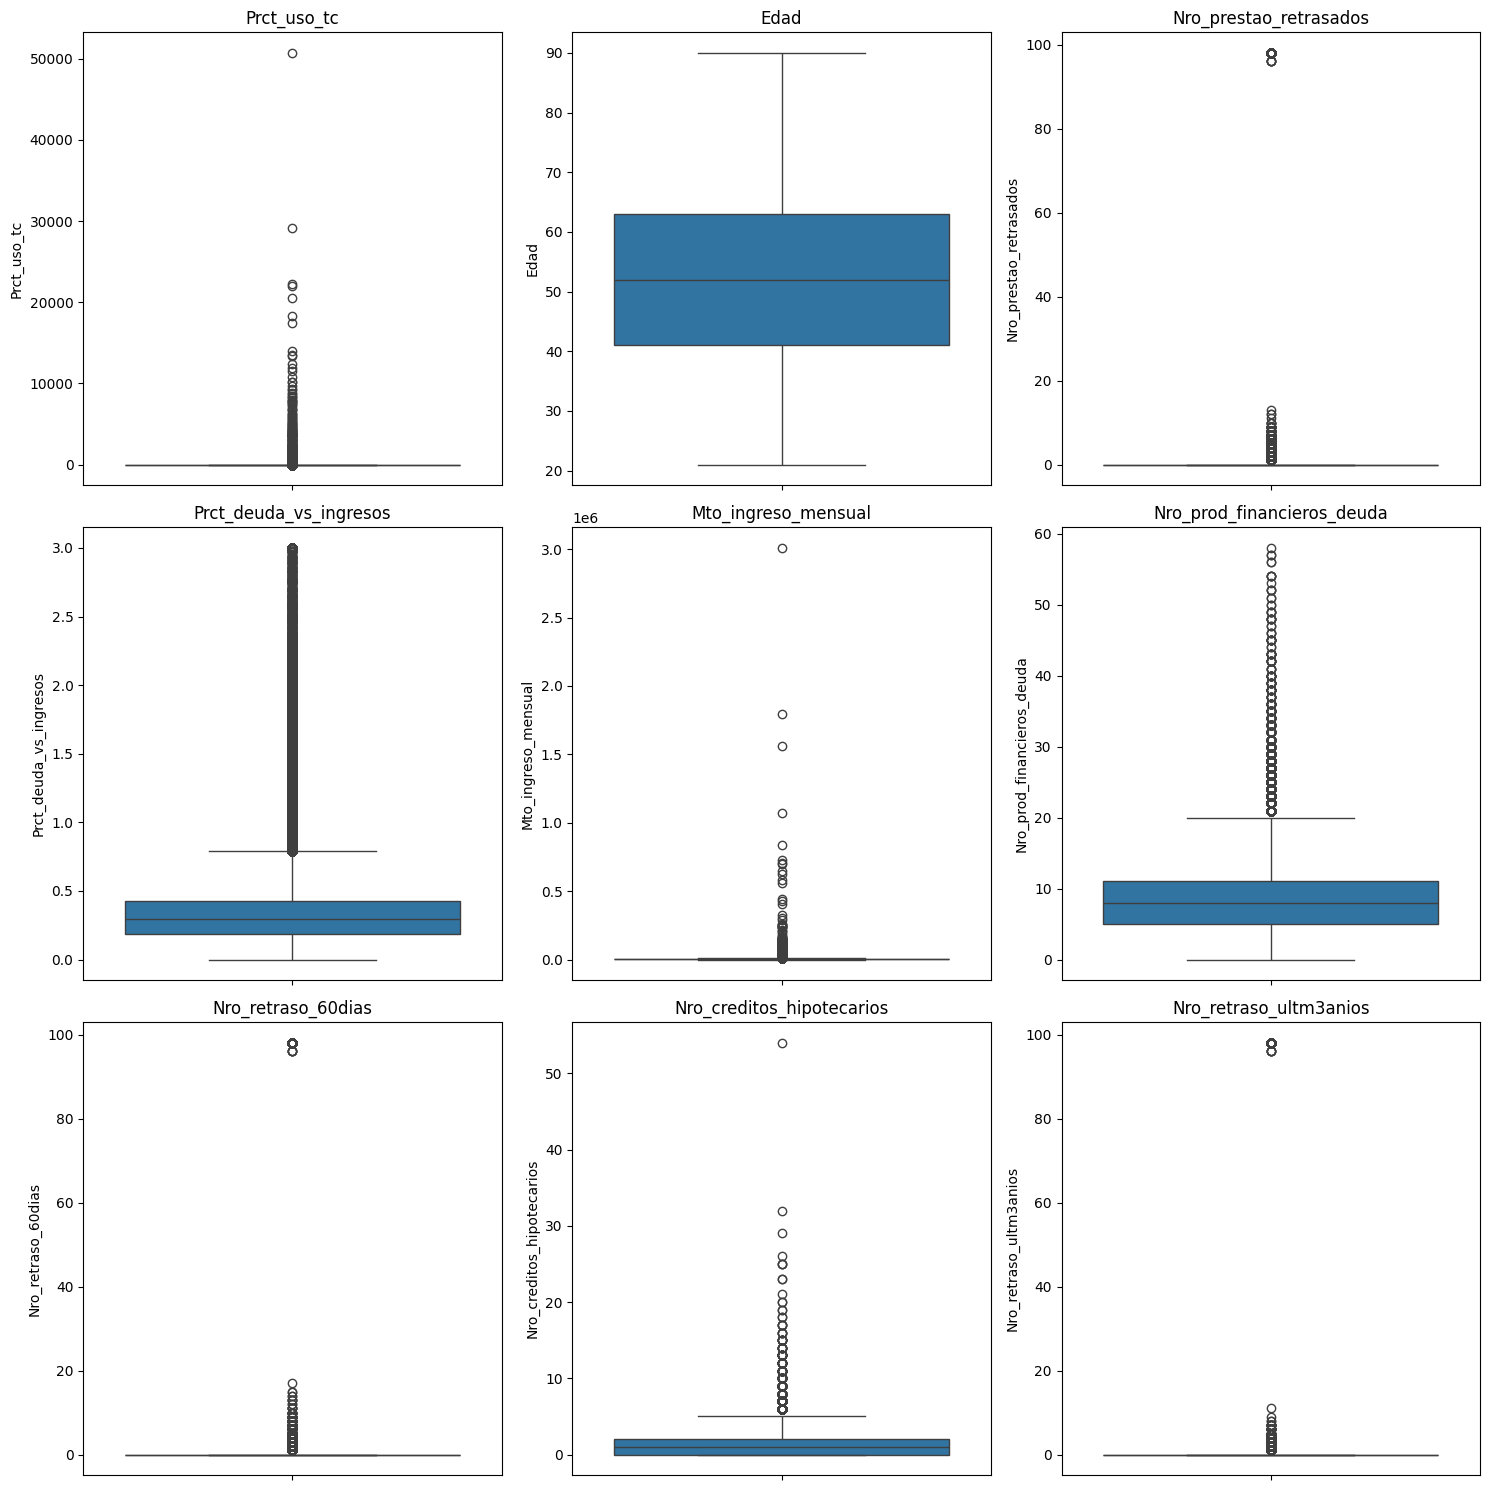

In [22]:
import math

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=credit_df[col], ax=axes[i])
    axes[i].set_title(col)
    
# Eliminar ejes vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Insights**:

- ``Prct_uso_tc``
    - Caja comprimida cerca de 0.
    - Muchos valores extremos enormes (hasta ~50000).
    - No tiene sentido económico si es porcentaje.
    - Esto no es simplemente asimetría. Hay valores claramente erróneos o mal escalados.
    - **Requiere limitación de valores severo o winsorización fuerte. Podría incluso limitarse a rango [0, 5] o [0, 10].**

- ``Edad``
    - Distribución muy limpia. Sin outliers problemáticos.
    - Rango lógico (18–90 después de limpieza).

- ``Nro_prestao_retrasados``
    - 75% en 0.
    - Cola derecha larga (hasta ~100). Conteo discreto.
    - No son “outliers” en sentido estadístico. Son clientes extremadamente riesgosos.
    - Aquí no conviene winsorizar agresivamente. En riesgo, valores altos son señal real.

- ``Prct_deuda_vs_ingresos``
    - Con el tratamiento aplicado, quedó razonable.
    - Variable clave.

- ``Mto_ingreso_mensual``
    - Altísima asimetría. 
    - Outliers enormes.
    - Cola derecha muy larga.
    - Ingresos reales pueden variar mucho. Pero esos millones extremos pueden distorsionar modelos lineales.
    - **Justificado usar log transform.**
    - **Winsorización suave (p99) recomendable.**

- ``Nro_prod_financieros_deuda``
    - Mediana ~8.
    - Cola hasta 60.
    - Distribución lógica. No parece error. Son clientes con muchos productos.

- ``Nro_retraso_60dias``
    - Mayoría 0.
    - Algunos extremos (~100). Discreta.
    - En riesgo, valores altos son señal fuerte.
    - No winsorizar. Dejar como está.

- ``Nro_creditos_hipotecarios``
    - Mismo patrón que otras moras. No tocar.

- ``Nro_dependiente``
    - Mayoría 0–1. 
    - Algunos hasta 20. No parece error.
    - No requiere winsorización.

In [23]:
# Outliers (winsorización suave para variables continuas)

def winsorize(series, lower=0.01, upper=0.99):
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lo, hi)

# Prct_uso_tc puede tener outliers muy grandes
if "Prct_uso_tc" in credit_df.columns:
    credit_df["Prct_uso_tc"] = winsorize(credit_df["Prct_uso_tc"])
    credit_df["Prct_uso_tc"] = credit_df["Prct_uso_tc"].clip(lower=0)  # % no negativo

# Calcular percentil 99
upper_cap = credit_df["Mto_ingreso_mensual"].quantile(0.99)
# Aplicar winsorización superior
credit_df["Mto_ingreso_mensual"] = credit_df["Mto_ingreso_mensual"].clip(upper=upper_cap)

# Ingreso (ya imputado) también puede tener cola pesada
credit_df[inc_col] = winsorize(credit_df[inc_col])

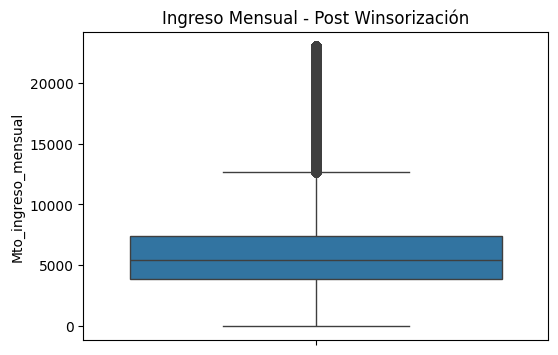

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(y=credit_df["Mto_ingreso_mensual"])
plt.title("Ingreso Mensual - Post Winsorización")
plt.show()

In [25]:
credit_df["log_ingreso"] = np.log1p(credit_df["Mto_ingreso_mensual"])
credit_df.drop(columns=["Mto_ingreso_mensual"], inplace=True)

**Insights**:

Se generó la variable log_ingreso para reducir asimetría y mejorar estabilidad del modelo. Se elimina Mto_ingreso_mensual para evitar redundancia y colinealidad

In [26]:
# Chequeos finales de calidad
# Sin nulos en variables críticas (target y numéricas)
critical_cols = ["Default", "Edad", inc_col, ratio_col, "Prct_uso_tc", "log_ingreso"]
existing_critical = [c for c in critical_cols if c in credit_df.columns]
na_check = credit_df[existing_critical].isnull().sum()

display(na_check)

# Validación simple: no negativos en variables de conteo (tras imputación/clip)
for c in count_cols:
    if c in credit_df.columns:
        assert (credit_df[c].dropna() >= 0).all(), f"Valores negativos persistentes en {c}"

Default                   0
Edad                      0
Prct_deuda_vs_ingresos    0
Prct_uso_tc               0
log_ingreso               0
dtype: int64

In [31]:
# Vista final
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149999 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Default                     149999 non-null  int64  
 1   Prct_uso_tc                 149999 non-null  float64
 2   Edad                        149999 non-null  int64  
 3   Nro_prestao_retrasados      149999 non-null  int32  
 4   Prct_deuda_vs_ingresos      149999 non-null  float64
 5   Nro_prod_financieros_deuda  149999 non-null  int32  
 6   Nro_retraso_60dias          149999 non-null  int32  
 7   Nro_creditos_hipotecarios   149999 non-null  int32  
 8   Nro_retraso_ultm3anios      149999 non-null  int32  
 9   Nro_dependiente             149999 non-null  int32  
 10  log_ingreso                 149999 non-null  float64
dtypes: float64(3), int32(6), int64(2)
memory usage: 10.3 MB


In [30]:
count_cols = [
    "Nro_prestao_retrasados",
    "Nro_prod_financieros_deuda",
    "Nro_retraso_60dias",
    "Nro_creditos_hipotecarios",
    "Nro_retraso_ultm3anios"
]

for c in count_cols:
    credit_df[c] = credit_df[c].round().astype("int32")

In [32]:
credit_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Default,149999.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.000000
Prct_uso_tc,149999.0,0.320491,0.352149,0.0,0.029867,0.154176,0.559044,1.092958
Edad,149999.0,52.285235,14.743048,21.0,41.000000,52.000000,63.000000,90.000000
Nro_prestao_retrasados,149999.0,0.421029,4.192795,0.0,0.000000,0.000000,0.000000,98.000000
Prct_deuda_vs_ingresos,149999.0,0.387257,0.455462,0.0,0.183708,0.296023,0.425508,3.000000
Nro_prod_financieros_deuda,149999.0,8.452776,5.145964,0.0,5.000000,8.000000,11.000000,58.000000
Nro_retraso_60dias,149999.0,0.265975,4.169318,0.0,0.000000,0.000000,0.000000,98.000000
Nro_creditos_hipotecarios,149999.0,1.018233,1.129772,0.0,0.000000,1.000000,2.000000,54.000000
Nro_retraso_ultm3anios,149999.0,0.240388,4.155193,0.0,0.000000,0.000000,0.000000,98.000000
Nro_dependiente,149999.0,0.737405,1.107020,0.0,0.000000,0.000000,1.000000,20.000000


**Insights**:

- No hay valores negativos indebidos
- No hay outliers explosivos
- Ratios están contenidos
- Variables de conteo mantienen señal real
- Distribuciones coherentes con contexto bancario

# 2. Análisis descriptivo (univariado/bivariado)

## 2.1 Análisis Descriptivo – Univariado

Esto nos permite entender:

- Distribución de cada variable
- Asimetría
- Concentración
- Señales potenciales de riesgo
- Calidad estadística

### 2.1.1 Variable Objetivo (Default)

In [35]:
credit_df["Default"].value_counts(normalize=True)

Default
0    0.93316
1    0.06684
Name: proportion, dtype: float64

**Insights**

- Dataset fuertemente desbalanceado: ~6.7% default (clase positiva), ~93.3% no Default (clase negativa)
- Accuracy no será útil (Predicciones correctas / Total de observaciones, no distingue entre clases. La clase minoritaria es la que importa. Es la que genera pérdidas. Un modelo que no detecta defaults no es bueno, aunque tenga un accuracy alto por acertar los casos de no default)
- Necesitamos ROC-AUC, GINI, Recall, Precision-Recall AUC
- Necesidad de threshold optimizado

### 2.1.2 Variables Continuas

**``log_ingreso``**

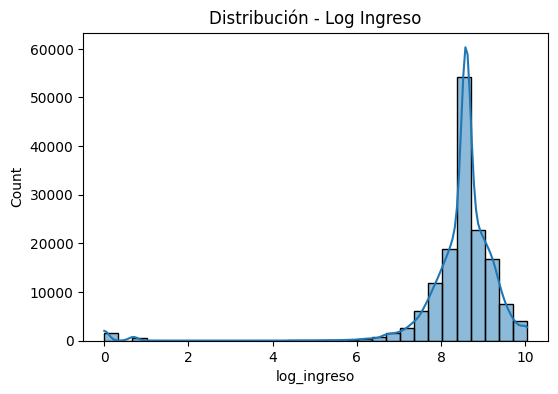

In [36]:
plt.figure(figsize=(6,4))
sns.histplot(credit_df["log_ingreso"], bins=30, kde=True)
plt.title("Distribución - Log Ingreso")
plt.show()

**Insights**

- Distribución mucho más simétrica que el ingreso original.
- Distribución claramente concentrada entre 8 y ~9.5.
- Pico pronunciado alrededor de ~8.5, 8.8.
- Se observan algunos valores muy pequeños (cerca de 0):
    - log_ingreso=log(1+ingreso), si log_ingreso ≈ 0 ⇒ ingreso ≈ 0
    - Eso significa que hay clientes con ingreso extremadamente bajo o cero.
    - En crédito retail:
        - Puede haber clientes sin ingresos formales
        - Puede haber errores de captura
        - Puede ser ingreso mínimo declarado
        - Pero debemos verificar si esos casos: Son muchos y si están asociados a mayor default.

In [42]:
# % de casos tienen ingreso cercano a cero
(credit_df["log_ingreso"] < 1).mean()*100

1.492676617844119

In [44]:
# Tasa de default
credit_df.loc[
    credit_df["log_ingreso"] < 1,
    "Default"
].mean()*100

3.707012058954891

**Insights**

- Muy pocos clientes tienen ingreso cercano a cero (1.49% del dataset)
- Tasa de default global ≈ 6.68%, tasa de default en ingreso cercano a cero ≈ 3.7% => Los clientes con ingreso extremadamente bajo NO tienen mayor default. De hecho, tienen menor tasa que el promedio.
- Puede tratarse de clientes jóvenes sin historial fuerte.
- Puede haber capturas incompletas de ingreso.
- El riesgo en este dataset parece estar más explicado por comportamiento pasado que por nivel de ingreso.
- Por lo que no se justifica un tratamiento adicional específico.

**``Prct_deuda_vs_ingresos``**

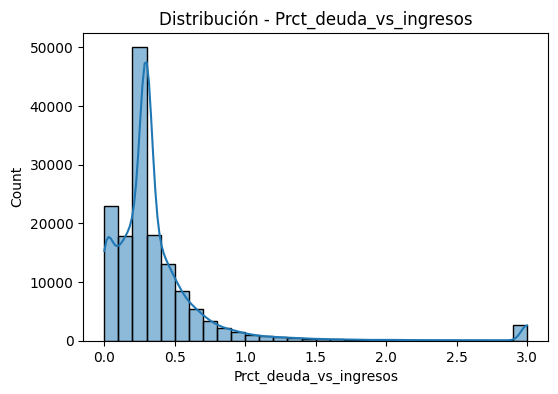

In [46]:
plt.figure(figsize=(6,4))
sns.histplot(credit_df["Prct_deuda_vs_ingresos"], bins=30, kde=True)
plt.title("Distribución - Prct_deuda_vs_ingresos")
plt.show()

**Insights**

- Distribución claramente asimétrica a la derecha.
- Alta concentración entre 0.1 y 0.5.
- Cola que se extiende hasta 3 (cap aplicado).
- Pequeña acumulación en el valor máximo (3), producto del corte realizado (Valores >300% no tienen interpretación real. Evita que el modelo aprenda ruido extremo.)
- La mayoría de clientes tiene:
    - Ratio deuda/ingreso < 50%
    - Un grupo menor entre 50% y 100%
    - Una minoría sobreendeudada (>100%)
    - Implica potencial poder discriminante

**``Prct_uso_tc``**

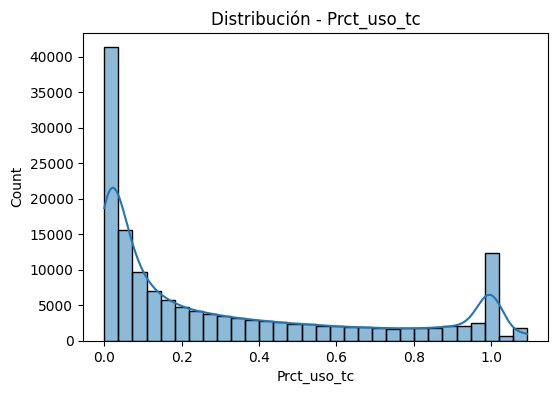

In [47]:
plt.figure(figsize=(6,4))
sns.histplot(credit_df["Prct_uso_tc"], bins=30, kde=True)
plt.title("Distribución - Prct_uso_tc")
plt.show()

**Insights**
- Alta concentración cerca de 0.
- Cola progresiva entre 0.1 y 0.8.
- Segundo “pico” cercano a 1 (uso cercano al 100%).
- Esto no es una distribución normal.
- Es claramente asimétrica y posiblemente bimodal.
- Podemos interpretar tres segmentos claros (lo que sugiere potencial capacidad discriminante en términos de riesgo):
    - Segmento 1 (verde): Uso bajo (0–20%). Clientes con baja utilización de tarjeta. Probablemente con mayor holgura financiera.
    - Segmento 2 (amarillo): Uso medio (20–80%). Clientes con uso activo pero controlado.
    - Segmento 3 (rojo): Uso alto (≈100%). Clientes que están al límite de su línea de crédito. Este último segmento suele ser altamente relevante en riesgo.

**Variables Discretas (Conteos)**

Aquí no usamos histograma tradicional, sino conteo.

**``Nro_retraso_60dias`` (Mora > 60 días)**

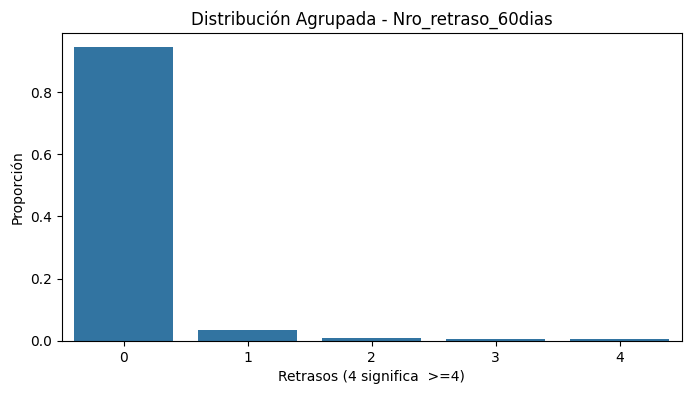

In [53]:
credit_df["retraso_60_grouped"] = credit_df["Nro_retraso_60dias"].apply(
    lambda x: x if x <= 3 else 4
)

vc_grouped = credit_df["retraso_60_grouped"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=vc_grouped.index, y=vc_grouped.values)
plt.title("Distribución Agrupada - Nro_retraso_60dias")
plt.ylabel("Proporción")
plt.xlabel("Retrasos (4 significa  >=4)")
plt.show()

**Insights**
- ~94–95% de los clientes tienen 0 retrasos >60 días.
- ~3–4% tienen 1 retraso.
- El resto (2, 3, ≥4) es marginal.
- La mayoría de clientes cumple. El riesgo está concentrado en minoría. => Potencial alta capacidad discriminante.

**``Nro_retraso_ultm3anios`` (Mora últimos 3 años)** 

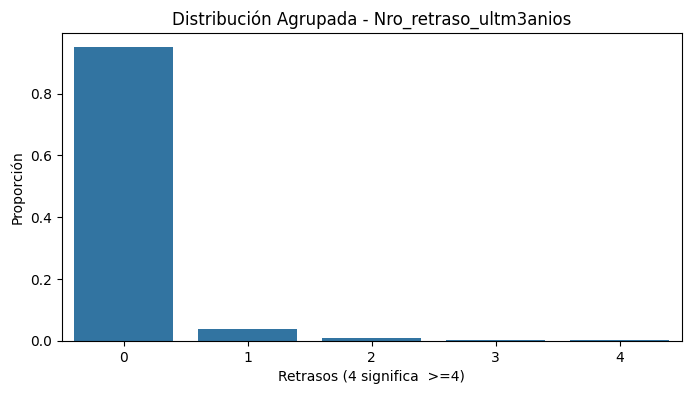

In [54]:
credit_df["retraso_ultm3anios_grouped"] = credit_df["Nro_retraso_ultm3anios"].apply(
    lambda x: x if x <= 3 else 4
)

vc_grouped = credit_df["retraso_ultm3anios_grouped"].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=vc_grouped.index, y=vc_grouped.values)
plt.title("Distribución Agrupada - Nro_retraso_ultm3anios")
plt.ylabel("Proporción")
plt.xlabel("Retrasos (4 significa  >=4)")
plt.show()

**Insights**
- Mismo análisis que ``Nro_retraso_60dias``.

**``Nro_prod_financieros_deuda`` (Productos financieros)**

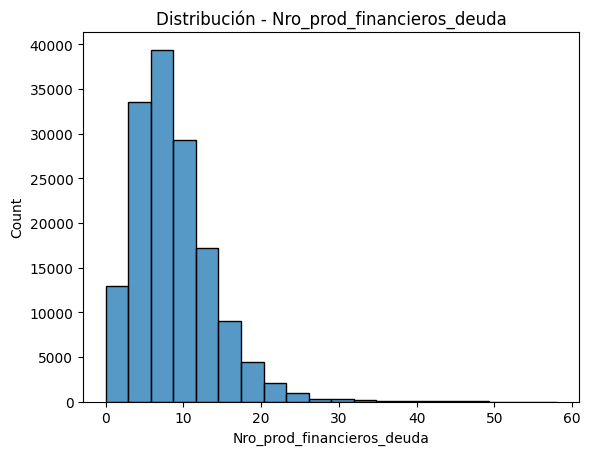

In [55]:
sns.histplot(credit_df["Nro_prod_financieros_deuda"], bins=20)
plt.title("Distribución - Nro_prod_financieros_deuda")
plt.show()

**Insights**

- Distribución unimodal.
- Pico entre 5 y 10 productos.
- Cola derecha hasta ~60.
- Asimetría moderada, no extrema.
- Su relación con el riesgo no es trivial y requiere análisis bivariado.

**``Nro_dependiente`` (Carga familiar)** 

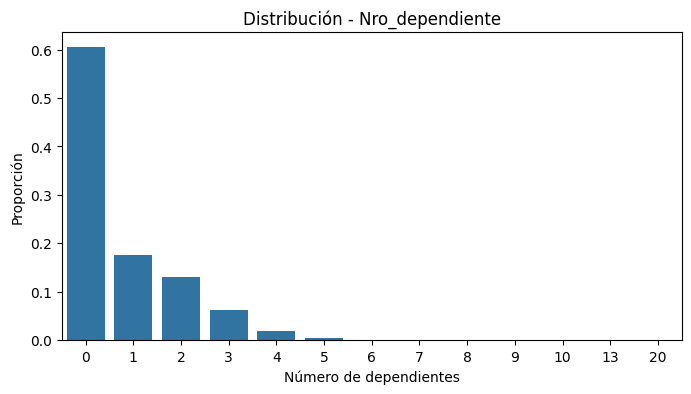

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular proporciones ordenadas
dep_dist = (
    credit_df["Nro_dependiente"]
    .value_counts(normalize=True)
    .sort_index()
)

plt.figure(figsize=(8,4))
sns.barplot(x=dep_dist.index, y=dep_dist.values)

plt.title("Distribución - Nro_dependiente")
plt.xlabel("Número de dependientes")
plt.ylabel("Proporción")
plt.show()

**Insights**

- ~60% tienen 0 dependientes. Distribución altamente concentrada en valores bajos.
- ~17–18% tienen 1
- ~12–13% tienen 2
- A partir de 3 cae rápidamente
- Cola muy pequeña hasta 20
- No es obvia la relación con el riesgo, ver análisis bivariado.


## 2.2 Análisis Descriptivo – Bivariado

Esto nos permite:

- Medir capacidad discriminante
- Buscar relaciones monotónicas
- Detectar no linealidades
- Identificar posibles transformaciones
- Entender drivers reales del default

**Comenzamos por el driver más fuerte: Mora >60 días (``Nro_retraso_60dias``)**

In [ ]:
# Tasa de default por número de retrasos
risk_60 = (
    credit_df
    .groupby("Nro_retraso_60dias")["Default"]
    .agg(["count", "mean"])
    .reset_index()
)

# Renombrar y convertir a porcentaje
risk_60.rename(columns={"mean": "default_rate_pct"}, inplace=True)
risk_60["default_rate_pct"] = risk_60["default_rate_pct"].round(2)*100

risk_60.head(10)

,Nro_retraso_60dias,count,default_rate_pct
0,0,141661,5.0
1,1,5243,34.0
2,2,1555,50.0
3,3,667,58.0
4,4,291,67.0
5,5,131,63.0
6,6,80,60.0
7,7,38,82.0
8,8,21,71.0
9,9,19,74.0


**Insights**

- El salto de riesgo entre:
    - 0 retrasos → 4.6%
    - 1 retraso → 33.7%

    Es brutal.

- Multiplica el riesgo por más de 7 veces.
- Esto solo ya explica una enorme parte del modelo.
- El gráfico muestra un punto extraño (100 retrasos), eso indica que:
    - Hay valores extremos muy raros.
    - Probablemente errores de captura o dataset sintético.
    - Pero como el count es muy bajo, no afectan el modelo significativamente.
- ``Nro_retraso_60dias`` es altamente discriminante, candidata fuerte a top variable del modelo.

**Mora últimos 3 años (>30 días)**

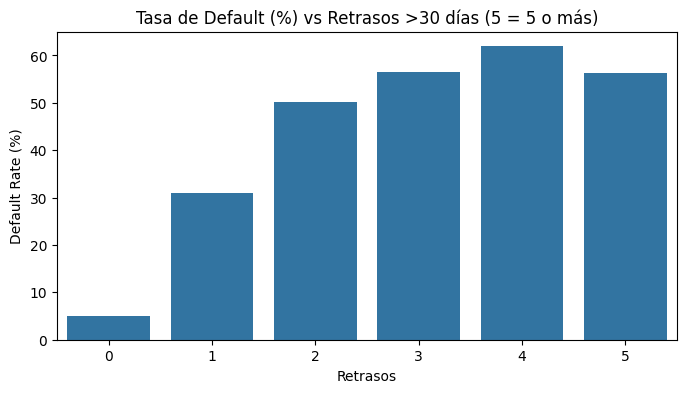

In [63]:
credit_df["retraso_30_grouped"] = credit_df["Nro_retraso_ultm3anios"].apply(
    lambda x: x if x <= 4 else 5
)

risk_30_grouped = (
    credit_df
    .groupby("retraso_30_grouped")["Default"]
    .mean()
    .reset_index()
)

risk_30_grouped["default_rate_pct"] = (risk_30_grouped["Default"] * 100).round(2)

plt.figure(figsize=(8,4))
sns.barplot(
    data=risk_30_grouped,
    x="retraso_30_grouped",
    y="default_rate_pct"
)

plt.title("Tasa de Default (%) vs Retrasos >30 días (5 = 5 o más)")
plt.xlabel("Retrasos")
plt.ylabel("Default Rate (%)")
plt.show()

**Insights**
- El salto entre:
    - 0 retrasos → ~5%
    - 1 retraso → ~31%

    Es masivo.

- Multiplica el riesgo por más de 6 veces.
- Esto es señal muy fuerte. Alto poder discriminante

**Ratio Deuda / Ingresos (variable continua)**

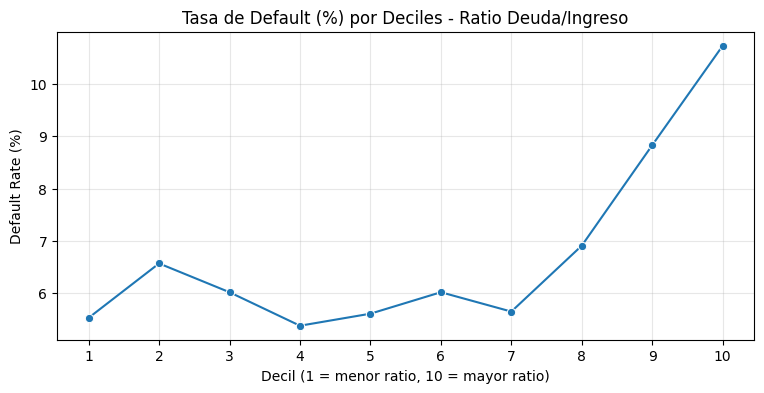

,ratio_decile,default_rate_pct
0,1,5.53
1,2,6.57
2,3,6.02
3,4,5.38
4,5,5.61
5,6,6.02
6,7,5.65
7,8,6.91
8,9,8.83
9,10,10.73


In [ ]:
# 1) Crear deciles numéricos (1 = menor ratio, 10 = mayor ratio)
credit_df["ratio_decile"] = (
    pd.qcut(
        credit_df["Prct_deuda_vs_ingresos"],
        q=10,
        labels=False,
        duplicates="drop"
    )
    .astype(int) + 1
)

# 2) Calcular default rate por decil (en %)
ratio_risk = (
    credit_df
    .groupby("ratio_decile")["Default"]
    .mean()
    .reset_index()
    .sort_values("ratio_decile")
)

ratio_risk["default_rate_pct"] = (ratio_risk["Default"] * 100).round(2)

# 3) Graficar (más legible que intervalos)
plt.figure(figsize=(9,4))
sns.lineplot(
    data=ratio_risk,
    x="ratio_decile",
    y="default_rate_pct",
    marker="o"
)

plt.title("Tasa de Default (%) por Deciles - Ratio Deuda/Ingreso")
plt.xlabel("Decil (1 = menor ratio, 10 = mayor ratio)")
plt.ylabel("Default Rate (%)")
plt.xticks(range(int(ratio_risk["ratio_decile"].min()), int(ratio_risk["ratio_decile"].max()) + 1))
plt.grid(True, alpha=0.3)
plt.show()

# tabla resumen
ratio_risk[["ratio_decile", "default_rate_pct"]]

**Insights**
- Ratio deuda:
    - Salto de 6% → 10% (moderado)
- Conclusión: Ratio deuda aporta señal adicional, pero no domina.

**``log_ingreso`` vs ``Default``**

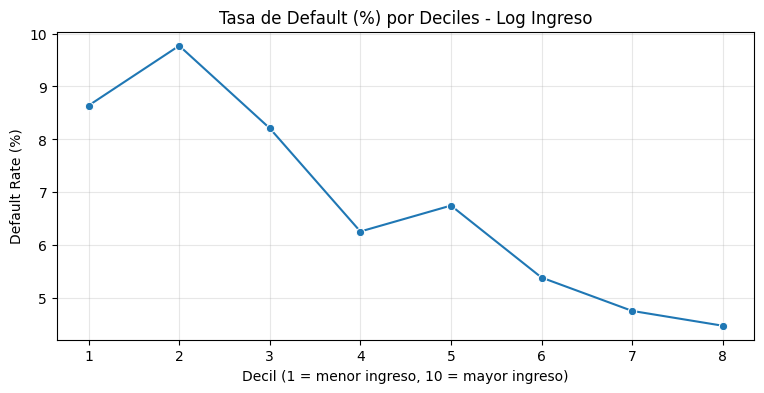

,ingreso_decile,default_rate_pct
0,1,8.64
1,2,9.77
2,3,8.21
3,4,6.26
4,5,6.75
5,6,5.39
6,7,4.76
7,8,4.48


In [ ]:
# 1) Crear deciles (1 = menor ingreso, 10 = mayor ingreso)
credit_df["ingreso_decile"] = (
    pd.qcut(
        credit_df["log_ingreso"],
        q=10,
        labels=False,
        duplicates="drop"
    ).astype(int) + 1
)

# 2) Calcular default rate por decil (en %)
ingreso_risk = (
    credit_df
    .groupby("ingreso_decile")["Default"]
    .mean()
    .reset_index()
    .sort_values("ingreso_decile")
)

ingreso_risk["default_rate_pct"] = (ingreso_risk["Default"] * 100).round(2)

# 3) Graficar
plt.figure(figsize=(9,4))
sns.lineplot(
    data=ingreso_risk,
    x="ingreso_decile",
    y="default_rate_pct",
    marker="o"
)

plt.title("Tasa de Default (%) por Deciles - Log Ingreso")
plt.xlabel("Decil (1 = menor ingreso, 10 = mayor ingreso)")
plt.ylabel("Default Rate (%)")
plt.xticks(range(int(ingreso_risk["ingreso_decile"].min()), int(ingreso_risk["ingreso_decile"].max()) + 1))
plt.grid(True, alpha=0.3)
plt.show()

# tabla resumen
ingreso_risk[["ingreso_decile", "default_rate_pct"]]

**Insights**

- Deciles bajos (1–3) → mayor tasa de default (~8–10%)
- A mayor ingreso → menor probabilidad de default.
- Deciles altos (~7–8) → ~4.5%
- Hay una relación inversa bastante clara.

**Uso de tarjeta (``Prct_uso_tc``)**

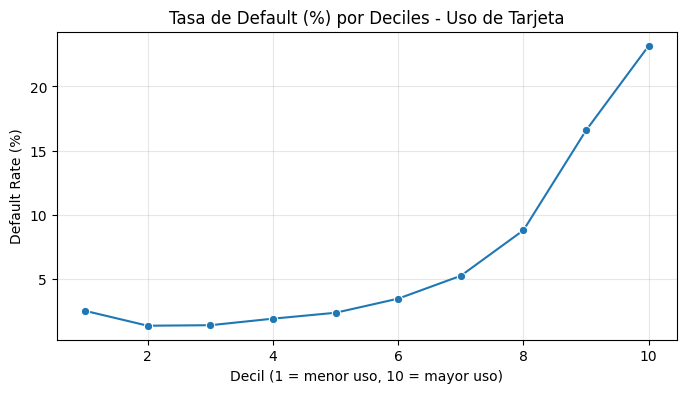

,uso_tc_decile,Default,default_rate_pct
0,1,0.025200,2.52
1,2,0.013600,1.36
2,3,0.014000,1.40
3,4,0.019133,1.91
4,5,0.023733,2.37
5,6,0.034736,3.47
6,7,0.052467,5.25
7,8,0.088000,8.80
8,9,0.165800,16.58
9,10,0.231733,23.17


In [68]:
# Crear deciles
credit_df["uso_tc_decile"] = (
    pd.qcut(
        credit_df["Prct_uso_tc"],
        q=10,
        labels=False,
        duplicates="drop"
    ).astype(int) + 1
)

# Calcular default rate por decil
uso_tc_risk = (
    credit_df
    .groupby("uso_tc_decile")["Default"]
    .mean()
    .reset_index()
)

uso_tc_risk["default_rate_pct"] = (uso_tc_risk["Default"] * 100).round(2)

# Graficar
plt.figure(figsize=(8,4))
sns.lineplot(
    data=uso_tc_risk,
    x="uso_tc_decile",
    y="default_rate_pct",
    marker="o"
)

plt.title("Tasa de Default (%) por Deciles - Uso de Tarjeta")
plt.xlabel("Decil (1 = menor uso, 10 = mayor uso)")
plt.ylabel("Default Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()

uso_tc_risk

**Insights**
- Observamos claramente:
    - Deciles 1–4 → riesgo muy bajo (~1–2%)
    - Deciles 5–7 → incremento moderado
    - Deciles 8–10 → salto fuerte
    - Decil 10 → ~23% default
- Clientes con uso cercano al 100%:
    - Menor liquidez disponible
    - Mayor dependencia del crédito rotativo
    - Mayor vulnerabilidad financiera
- Candidato top del modelo

**Número de productos financieros**

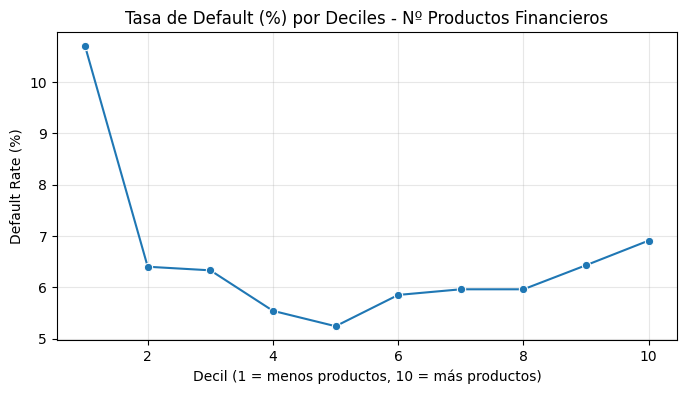

,prod_decile,Default,default_rate_pct
0,1,0.107029,10.70
1,2,0.064002,6.40
2,3,0.063336,6.33
3,4,0.055388,5.54
4,5,0.052428,5.24
5,6,0.058476,5.85
6,7,0.059643,5.96
7,8,0.059572,5.96
8,9,0.064295,6.43
9,10,0.069073,6.91


In [69]:
# Crear deciles
credit_df["prod_decile"] = (
    pd.qcut(
        credit_df["Nro_prod_financieros_deuda"],
        q=10,
        labels=False,
        duplicates="drop"
    ).astype(int) + 1
)

# Calcular default rate por decil
prod_risk = (
    credit_df
    .groupby("prod_decile")["Default"]
    .mean()
    .reset_index()
)

prod_risk["default_rate_pct"] = (prod_risk["Default"] * 100).round(2)

# Graficar
plt.figure(figsize=(8,4))
sns.lineplot(
    data=prod_risk,
    x="prod_decile",
    y="default_rate_pct",
    marker="o"
)

plt.title("Tasa de Default (%) por Deciles - Nº Productos Financieros")
plt.xlabel("Decil (1 = menos productos, 10 = más productos)")
plt.ylabel("Default Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()

prod_risk

**Insights**
- El mayor riesgo no está en quienes tienen muchos productos. Está en quienes tienen muy pocos.
- Esto es interesante desde negocio: Poca bancarización puede asociarse a mayor riesgo.
- Aporta información para el modelo.


**Estado actual del análisis bivariado**

Hasta ahora, ranking preliminar de drivers:

1️ - Mora >60 días

2 - Uso de tarjeta

3 - Mora >30 días

4 - Ratio deuda

5 - Ingreso

6️ - Nº productos